```{eval-rst}
.. include:: sinebow.rst

```

{sinebow24}`Cell diameter`
==================================

The idea of an average cell diameter sounds intuitive, but the standard implementation of this idea fails to capture that intuition. 
The go-to method (adopted in Cellpose) is to calculate the cell diameter as the diameter of the circle of equivalent area. As I will demonstrate, 
this fails for anisotropic (non-circular) cells. As an alternative, I devised the following simple diameter metric: 

```python
diameter = 2*(dimension+1)*np.mean(distance_field)
```

Because the distance field represents the distance to the *closest* boundary point, it naturally captures the intrinsic 'thickness' of a region (in any dimension). Averaging the field over the region 
(the first moment of the distribution) distills this information into a number that is intuitively proportional to the thickness of the region. For example, if a region is made up of a bungle of many 
thin fragments, its mean distance is far smaller than the mean distance of the circle of equivalent area. But to call it a 'diameter', I wanted this metric to match the diameter of a sphere in any dimension. 
So, by calculating the average of distance field of an n-sphere, we get the above expression for the the diameter of an n-sphere given the average of the distance field over the volume. 

{header-2}`Example cells`
-------------------------
Filamenting bacterial cells often exhibit constant width but increasing length. This dataset comes from the deletion of the essential gene *ftsN* in *Acinetobacter baylyi*. 

In [ ]:
%load_ext autoreload
%autoreload 2

Using Python-MIP package version 1.15.0
WRITING LOG OUTPUT TO /home/kcutler/.cellpose/run.log
4 -color algorthm failed,trying again with 5 colors. Depth 0


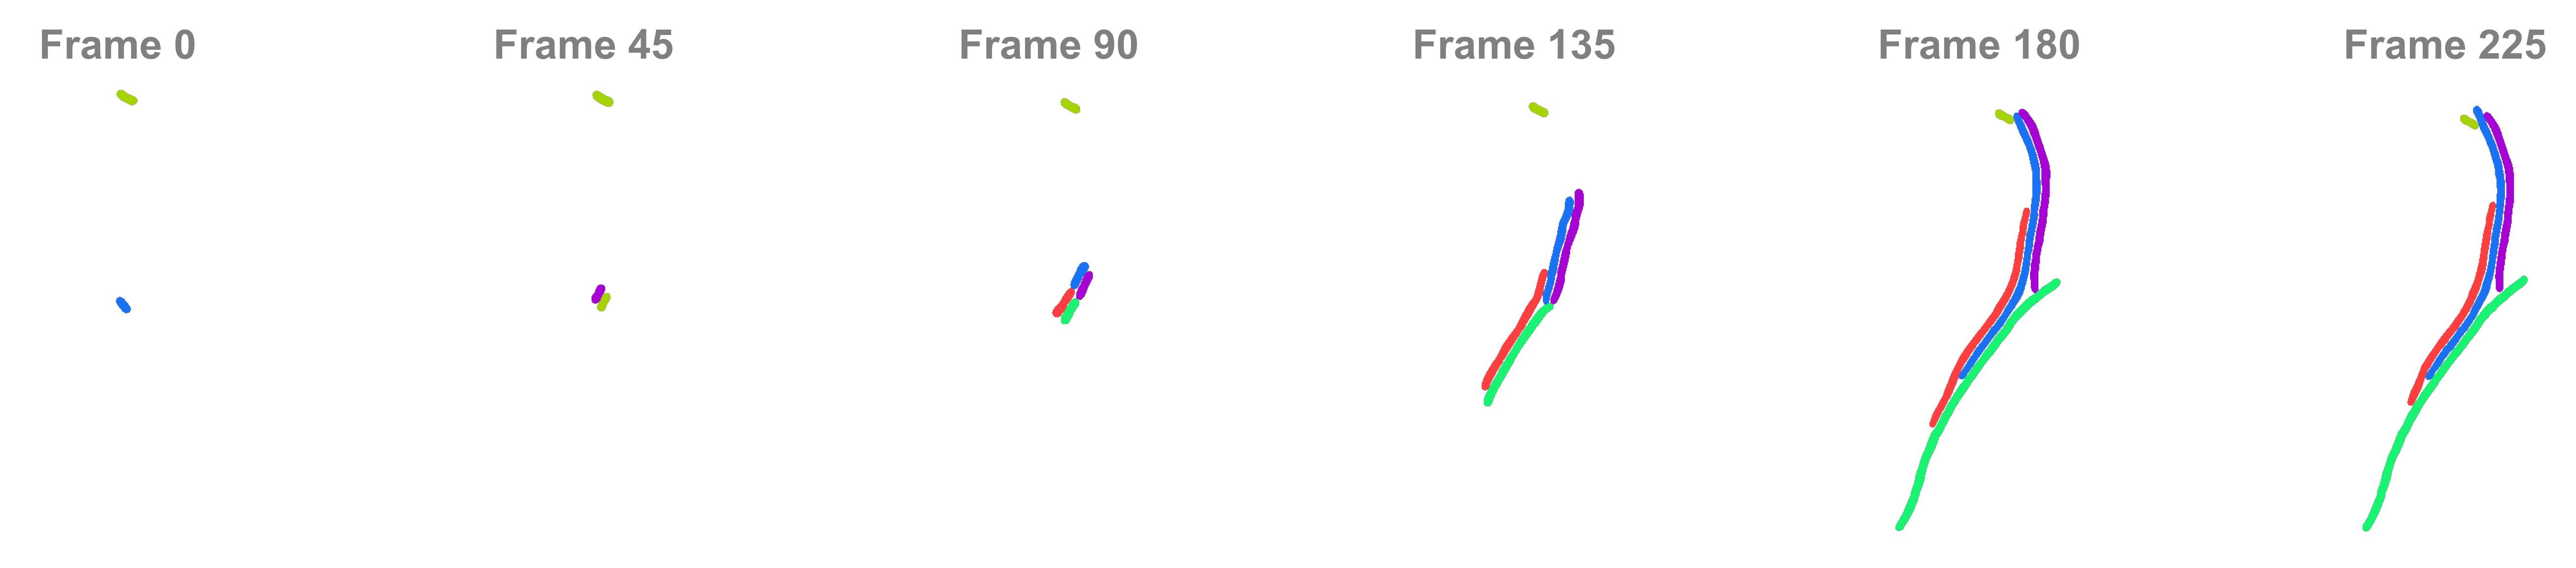

In [ ]:
from pathlib import Path
from omnirefactor import utils, plot, models, io, dynamics
import os, sys, io
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')
import matplotlib as mpl
%matplotlib inline
mpl.rcParams['figure.dpi'] = 600

# # Save a reference to the original stdout stream
# old_stdout = sys.stdout

# # Redirect stdout to a StringIO object
# sys.stdout = io.StringIO()


import omnirefactor
from omnirefactor.plot import imshow
import tifffile
omnidir = Path(omnirefactor.__file__).parent.parent
basedir = os.path.join(omnidir,'docs','_static')
nm = 'ftsZ'
masks = tifffile.imread(os.path.join(basedir,nm+'_masks.tif'))
mnc = omnirefactor.plot.apply_ncolor(masks)

f = 1
c = [0.5]*3
fontsize=10
dpi = mpl.rcParams['figure.dpi']
Y,X = masks.shape[-2:]
szX = max(X//dpi,2)*f
szY = max(Y//dpi,2)*f

# T = [50,80,100,150,180,240]
T = range(0,len(masks),45)
titles = ['Frame {}'.format(t) for t in T]
ims = [mnc[t] for t in T]
N = len(titles)

fig, axes = plt.subplots(1,N, figsize=(szX*N,szY))  
fig.patch.set_facecolor([0]*4)

for i,ax in enumerate(axes):
    ax.imshow(ims[i])
    ax.axis('off')
    ax.set_title(titles[i],c=c,fontsize=fontsize,fontweight="bold")

plt.subplots_adjust(wspace=0.1)
plt.show()

# Restore the original stdout stream
# sys.stdout = old_stdout

{header-2}`Compare diameter metrics`
------------------------------------
By plotting the mean diameter (averaged over all cells after being computed per-cell, of course), we find that 
the 'circle diameter metric' used in Cellpose rises drastically with cell length, but the 'distance diameter metric' of Omnipose remains nearly constant. If we tried to use the former to train a `SizeModel()`, images would get downsampled 
heavily to the point of cells being **too thin to segment**, and that is assuming that the model can reliably detect the highly nonlocal property of cell length in an image instead of the local property of 
cell width (at least, what we humans would point to and *call* cell width). 

Of course, we also want to measure *accurate* cell widths, and it turns out that the Omnipose metric scales linearly with width perfectly spherical objects and quadratically for infinite rods. Real cells fall somewhere between these two extremes, so we have also recently developed another metric for a pill (rod with hemispherical caps) that computes the cap radius `R` and rod length `L` from the area and integrated distance field. 

Manual inspection of these masks shows that the diameter of the cells stays at a roughly constant 8px. The measured pill diameter `2R` matches well with this, and the Omnipose metric correlates but must be corrected with a factor of 0.75 to match the absolute scale. 

In [ ]:
import fastremap
n = len(masks)
diam_old = np.zeros(n)
cell_num = np.zeros(n)
x = range(n)
pL = np.zeros(n)
pR = np.zeros(n)
oL = np.zeros(n)
oD = np.zeros(n)
for k in x:
    m = masks[k]
    fastremap.renumber(m,in_place=True)
    cell_num[k] = m.max()
    diam_old[k] = utils.diameters(m,omni=False)[0]
    pR[k], pL[k] = omnirefactor.core.diameters(m,pill=True)
    oD[k], oL[k] = omnirefactor.core.diameters(m,pill=False,return_length=True)
    

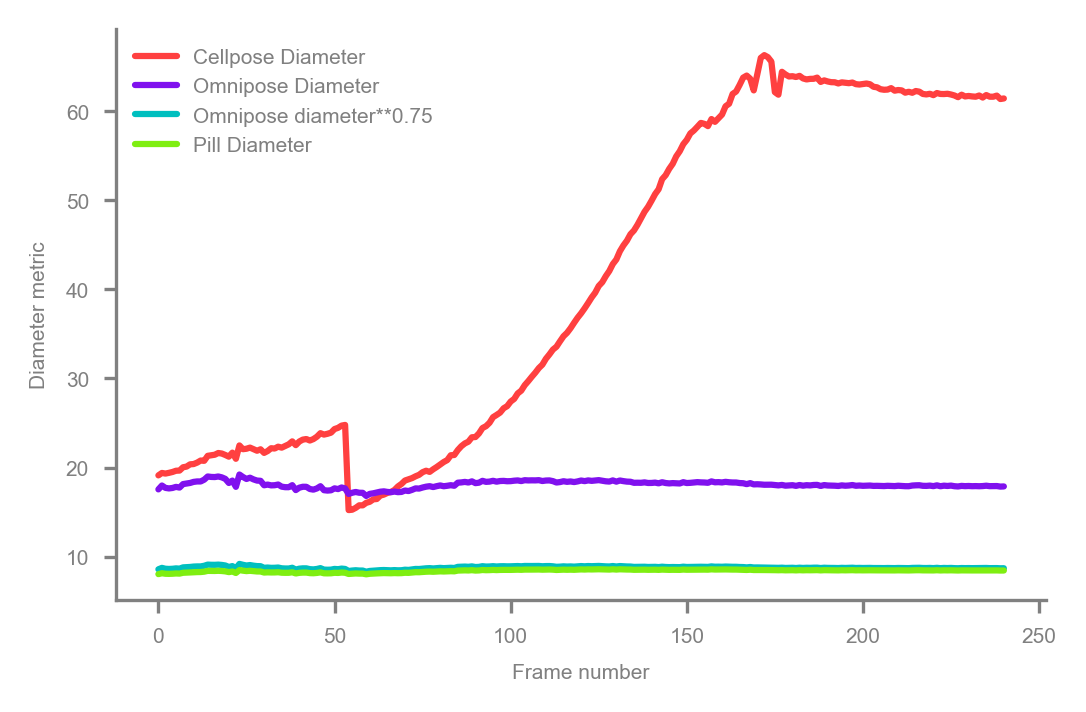

In [ ]:
from omnirefactor.utils import sinebow
golden = (1 + 5 ** 0.5) / 2
sz = 4
labelsize = 5

%matplotlib inline

plt.style.use('dark_background')
mpl.rcParams['figure.dpi'] = 300 

axcol = [0.5]*3+[1]
f = 0.75
labels = ['Cellpose Diameter','Omnipose Diameter',f'Omnipose diameter**{f}','Pill Diameter']
lines = [diam_old,oD,
         # 2*((oD/2)**0.5),
         oD**f,
         pR*2]

N = len(labels)
colors = sinebow(N,offset=0)
background_color = [0]*4

fig = plt.figure(figsize=(sz, sz/golden),frameon=False) 
fig.patch.set_facecolor(None)

ax = plt.axes()
maxnorm = 0
minmaxnorm = 0
log = 0
for line,label,color in zip(lines,
                            labels,
                            [colors[i+1] for i in range(N)]):
    l = line.copy()
    if maxnorm:
        l /= l.max()
    elif minmaxnorm:
        l = omnirefactor.utils.rescale(l)
    
    ax.plot(x,l,c=color,label=label)



ax.legend(loc='best', frameon=False,labelcolor=axcol, fontsize = labelsize)
ax.tick_params(axis='both', which='major', labelsize=labelsize,length=3, direction="out",colors=axcol,bottom=True,left=True)
ax.tick_params(axis='both', which='minor', labelsize=labelsize,length=3, direction="out",colors=axcol,bottom=True,left=True)
ax.set_ylabel('Diameter metric', fontsize = labelsize,c=axcol)
ax.set_xlabel('Frame number', fontsize = labelsize, c=axcol)
ax.set_facecolor(background_color)

for spine in ax.spines.values():
    spine.set_color(axcol)
    
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(False)
if log: ax.set_yscale('log')

plt.show()

In [ ]:
from skimage.morphology import skeletonize, medial_axis

# skel = np.array([np.sum(skeletonize(m)) for m in masks])
import edt
def get_skels(masks):
    skels = [[]]*len(masks)
    for k,m in enumerate(masks):
        dt = edt.edt(m)
        inner = dt>2
        skels[k] = skeletonize(inner, method='lee')
        
    return skels
skels = get_skels(masks)
sl = np.array([s.sum() for s in skels])
# dm = np.array([d[s==1].mean() for d,s in zip(dists,skels)])

In [ ]:
dists[0].shape,skels[0].shape

((23, 33), (603, 234))

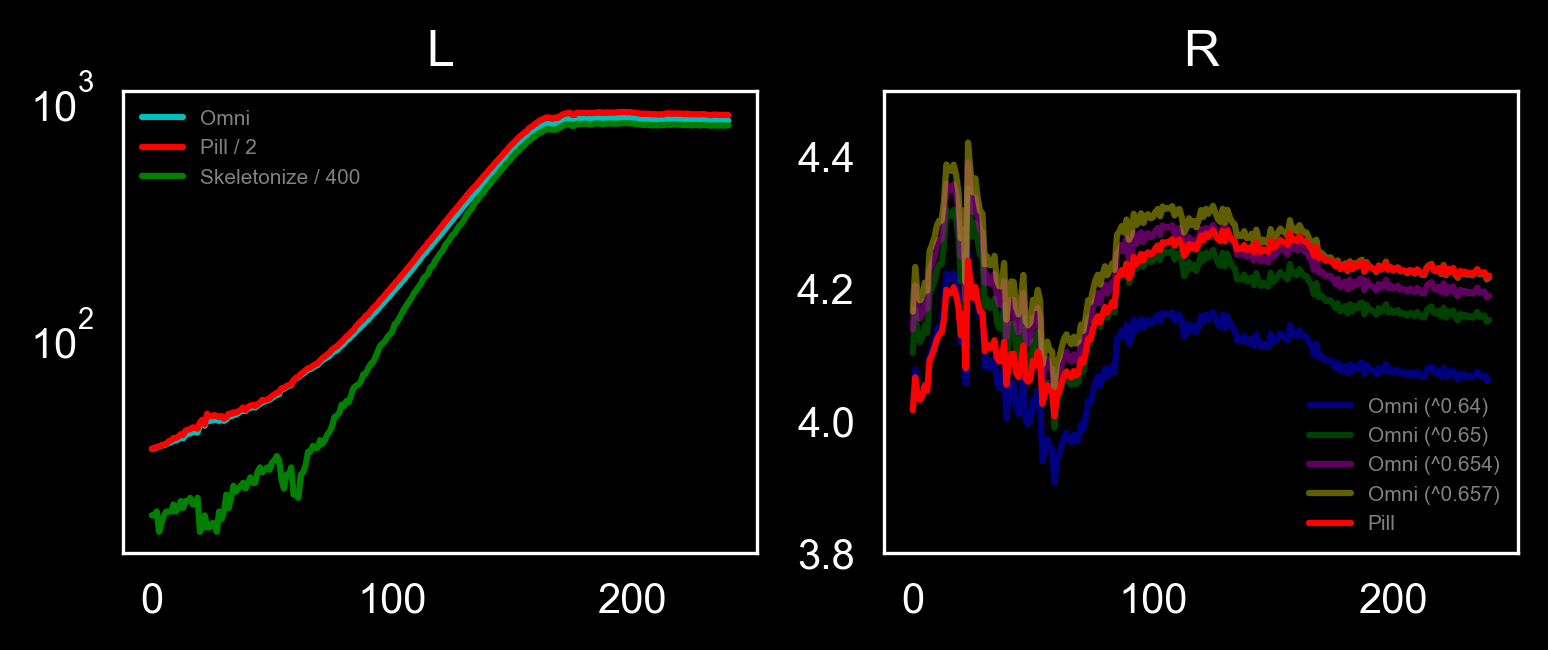

In [ ]:
fig,axes = plt.subplots(1,2, figsize=(6,2))
ax = axes[0]
ax.plot(x,oL,c='c',label='Omni')
ax.plot(x,L/2,c='r',label='Pill / 2')
ax.plot(x,sl/400,c='g',label='Skeletonize / 400')

# ax.plot(x,(L/2+2*R),c='r')
ax.set_title('L')
ax.set_yscale('log')
ax.grid(0)
ax.legend(loc='best', frameon=False,labelcolor=axcol, fontsize = labelsize)


ax = axes[1]
a = .5
oR = oD/2
# ax.plot(x,oR**0.5,c='c',label='Omni (sqrt)')
g = .64
ax.plot(x,oR**g,c='b',label=f'Omni (^{g})',alpha=a)
g = .65
ax.plot(x,oR**g,c='g',label=f'Omni (^{g})',alpha=a)
g = .654
ax.plot(x,oR**g,c='m',label=f'Omni (^{g})',alpha=a)
g = .657
ax.plot(x,oR**g,c='y',label=f'Omni (^{g})',alpha=a)

ax.set_ylim(3.8,4.5)
# plt.plot(x,L/2.11,c='r')
ax.plot(x,R,c='r',label='Pill')
ax.set_title('R')
# ax.set_yscale('log')
ax.grid(0)
ax.legend(loc='best', frameon=False,labelcolor=axcol, fontsize = labelsize)


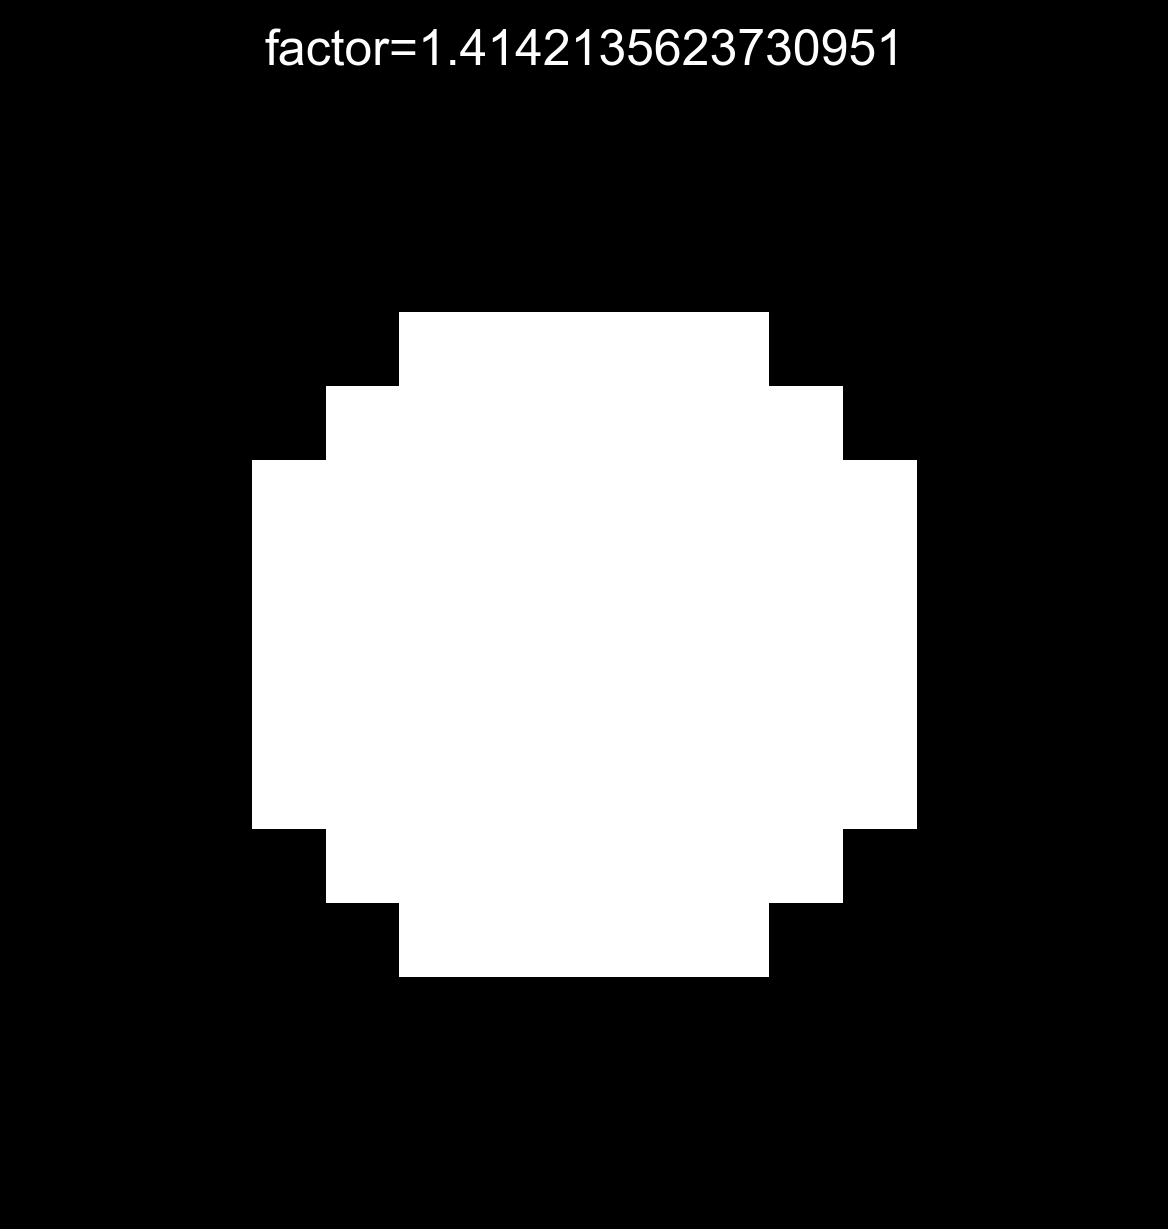

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def create_pill_mask(R, L, f = np.sqrt(2)):
    # Determine the size of the image
    height = 2 * R# +2 for 1px boundary at top and bottom
    width = L + 2*R  # +2 for 1px boundary on left and right
    
    # Create an empty image
    pad = 3
    imh = height+2*pad + 1
    imw = width+2*pad +1
    # imh = 2*(imh//2)+1 # make odd
    # imw = 2*(imw//2)+1
    
    mask = np.zeros((imh,imw), dtype=np.uint8)
    
    # Calculate the center of the pill shape
    center_x = imw // 2
    center_y = imh // 2
    
    # Draw the rectangular part of the pill
    mask[center_y - R:center_y + R+1, R+pad:L+R+pad+1] = 1
    
    # Create a grid of coordinates
    y, x = np.ogrid[:imh, :imw]


    
    # Draw the left semicircle
    left_center_x = R+pad
    left_circle = (x - left_center_x) ** 2 + (y - center_y) ** 2 <= f*(R ** 2)
    # left_circle = np.round((x - left_center_x) ** 2 + (y - center_y) ** 2) <= f*(R ** 2)
    
    mask[left_circle] = 1
    
    # Draw the right semicircle
    # right_center_x = width - R - 2
    right_center_x = L+R+pad
    right_circle = (x - right_center_x) ** 2 + (y - center_y) ** 2 <= f*(R ** 2)
    # right_circle = np.round((x - right_center_x) ** 2 + (y - center_y) ** 2) <= f*(R ** 2)
    
    mask[right_circle] = 1
    
    return mask

# Parameters for the pill shape
R = 4
L = 0

# Create the mask
f = np.sqrt(2)
# f = 1
pill_mask = create_pill_mask(R, L,f=f)

# Display the mask
plt.imshow(pill_mask, cmap='gray')
# plt.title('factor=sqrt(2)')
plt.title(f'factor={f}')

plt.axis('off')
plt.show()


In [ ]:
r = 20
# lengths = range(r,20*r,r)
lengths = range(0,101,5)

N = len(lengths)
f = 1.25
pills = [create_pill_mask(r, l, f=f) for l in lengths]
theta = np.pi/4
# pills = [omnirefactor.utils.rotate(m,theta,output_shape=[np.max(m.shape)]*2,order=0) for m in pills]
pills = [omnirefactor.utils.rotate(m,theta,output_shape=[np.max(m.shape)]*2,order=2)>0 for m in pills]

dists = [edt.edt(m) for m in pills]

std = np.zeros(N)
for k,d in enumerate(dists):
    std[k] = np.std(d[d>0])
# plt.plot(lengths,std)
n = len(lengths)
x = range(n)
L = np.zeros(n)
R = np.zeros(n)
oL = np.zeros(n)
oD = np.zeros(n)
A = np.zeros(n)
rR = np.zeros(n)
rL = np.zeros(n)

for k in x:
    m = pills[k]>0
    A[k] = np.sum(m)
    fastremap.renumber(m,in_place=True)    
    R[k], L[k] = omnirefactor.core.diameters(m,pill=True)
    oD[k], oL[k] = omnirefactor.core.diameters(m,pill=False,return_length=True)

    d = dists[k]
    D = np.sum(d[m])
    dP = np.stack(np.gradient(d))
    w = np.sqrt(np.sum(dP**2,axis=0))<0.5
    rR[k] = (np.sum(w[m]*d[m])/np.sum(w[m]))-1
    rL[k] = (3*D - np.pi*(rR[k]**4)) / (rR[k]**3)
    # rL[k] = np.sum(w[m])

oR = oD/2




import edt
def get_skels(masks):
    skels = [[]]*len(masks)
    for k,m in enumerate(masks):
        dt = edt.edt(m)
        inner = dt>2
        skels[k] = skeletonize(inner, method='lee')
        
    return skels
skels = get_skels(pills)
sl = np.array([s.sum() for s in skels])
rm = np.array([d[s!=0].mean() for d,s in zip(dists,skels)])

/tmp/ipykernel_631066/4121182959.py:39: RuntimeWarning: invalid value encountered in divide
  rR[k] = (np.sum(w[m]*d[m])/np.sum(w[m]))-1


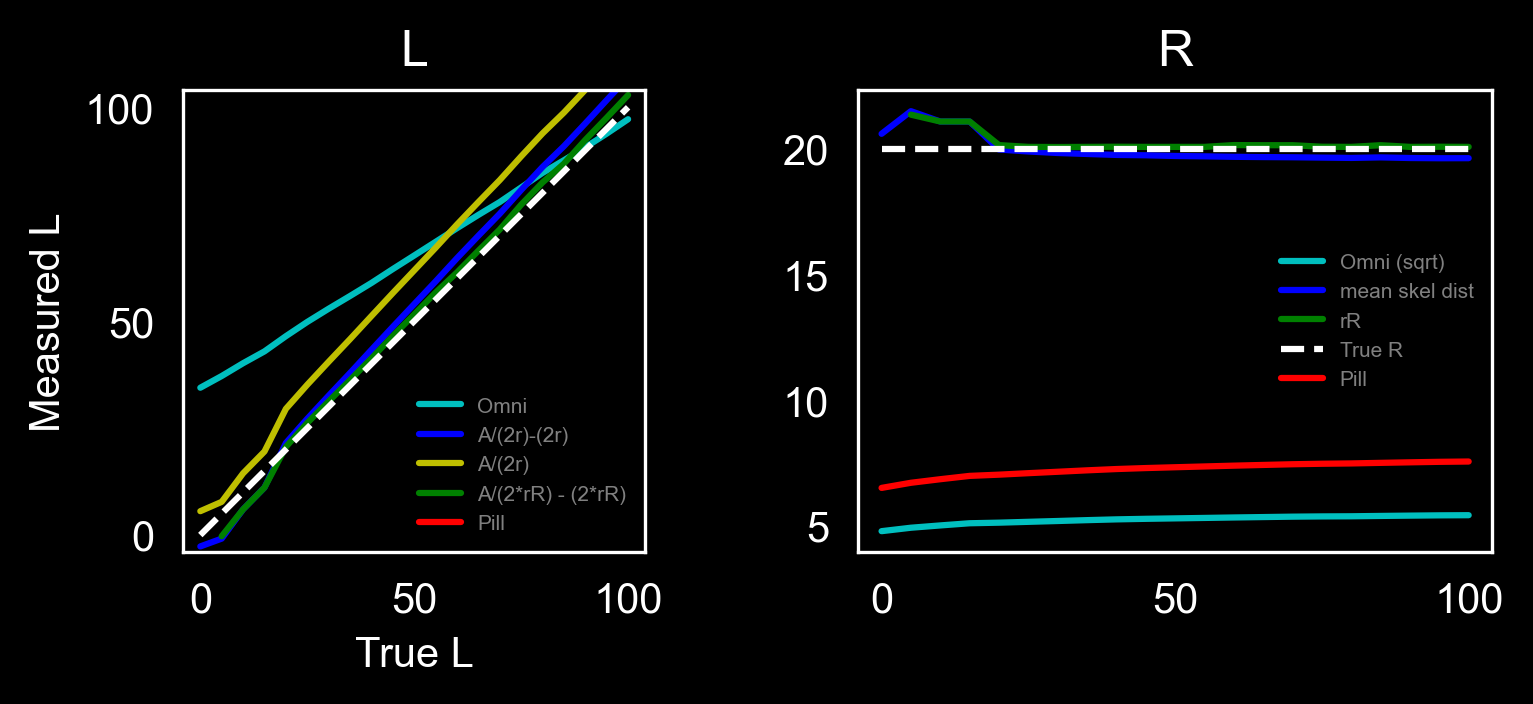

In [ ]:
fig,axes = plt.subplots(1,2, figsize=(6,2))
ax = axes[0]
# ax.plot(lengths,oL**1.3 - 24,c='c',label='Omni')
ax.plot(lengths,oL,c='c',label='Omni')
var = std**2
# ax.plot(lengths, oL*std/2, c='g',label='Omni*std')

# ax.plot(lengths, A/dm-dm, c='b',label='A/dm')
ax.plot(lengths, A/(2*(rm-1))-(2*(rm-1)), c='b',label='A/(2r)-(2r)')
ax.plot(lengths, A/(2*(rm-1))-1.6*(rm-1), c='y',label='A/(2r)')
# ax.plot(lengths, A/(2*(rR)) - (2*(rR)), c='g',label='A/(gradient-weighted average dist)')
# ax.plot(lengths, (rL+rR)/1.15, c='g',label='rL')
# ax.plot(lengths, rL, c='g',label='rL')
# ax.plot(lengths, rL, c='g',label='Pill(rR)')
ax.plot(lengths, A/(2*rR) - (2*rR), c='g',label='A/(2*rR) - (2*rR)')







# ax.plot(lengths,A/(oR) +oR - 22,c='c',label='Omni')

o = 0
# ax.plot(lengths,L-o,c='r',label=f'Pill-{o}')
ax.plot(lengths,L,c='r',label=f'Pill')

ax.plot(lengths,lengths,'--',c='w')


# ax.plot(x,(L/2+2*R),c='r')
ax.set_title('L')
# ax.set_yscale('log')
ax.grid(0)
ax.legend(loc='best', frameon=False,labelcolor=axcol, fontsize = labelsize)
ax.set_xlabel('True L')
ax.set_ylabel('Measured L')

ax.set_ylim(lengths[0],lengths[-1])
# ax.set_xlim(lengths[0],lengths[-1])
ax.set_xlim(lengths[0]-pad,lengths[-1]+pad)
ax.set_ylim(lengths[0]-pad,lengths[-1]+pad)

ax.set_xticks(lengths[::10])
ax.set_yticks(lengths[::10])

ax.set_aspect(1)
ax = axes[1]
a = .5
# ax.plot(lengths,oR,c='c',label='Omni')
ax.plot(lengths,oR**0.5,c='c',label='Omni (sqrt)')
# ax.plot(lengths,3*(oR**(std/oR)),c='g',label='Omni_2')
# ax.plot(lengths,2*oR/std,c='g',label='Omni / std')
# ax.plot(lengths,std*2,c='b',label='2*std')
ax.plot(lengths,rm-1,c='b',label='mean skel dist')
ax.plot(lengths, rR, c='g',label='rR')

ax.hlines(r,lengths[0],lengths[-1],'w','--',label = 'True R')

# ax.set_ylim(3.8,4.5)
# plt.plot(x,L/2.11,c='r')
ax.plot(lengths,R,c='r',label='Pill')
ax.set_title('R')

ax.set_xticks(lengths[::10])
pad = 4
ax.set_xlim(lengths[0]-pad,lengths[-1]+pad)

# ax.set_ylim(0,r+1)


# ax.set_yscale('log')
ax.grid(0)
ax.legend(loc='best', frameon=False,labelcolor=axcol, fontsize = labelsize)


5.0


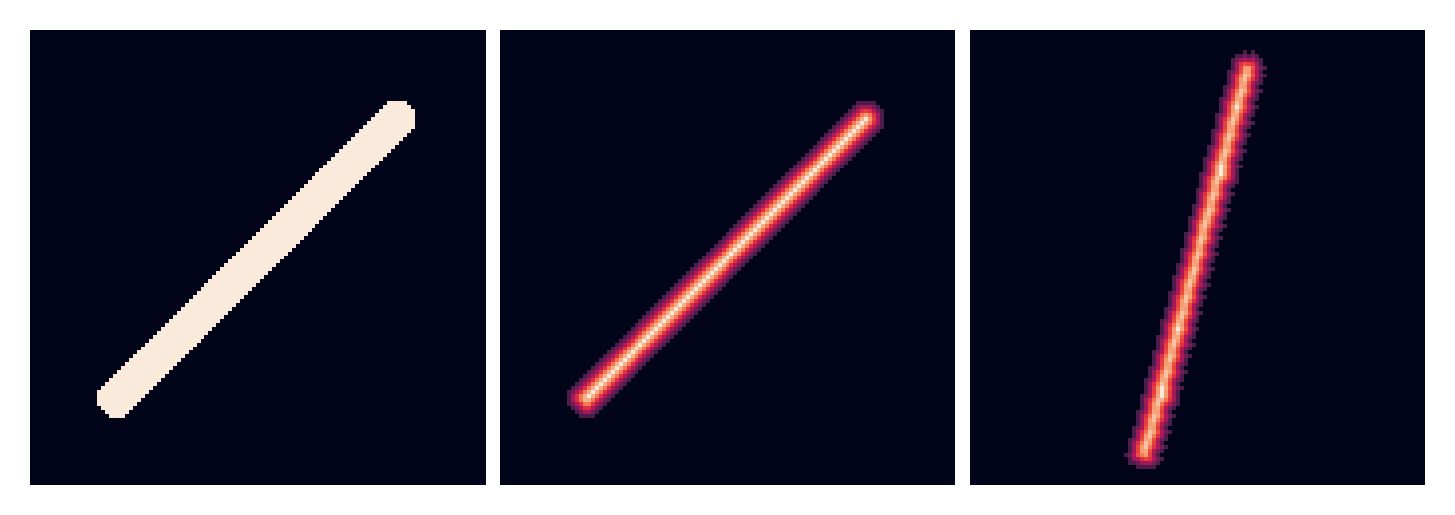

In [ ]:
theta = np.pi/3
m = pills[k]
d = dists[k]
m_rot = omnirefactor.utils.rotate(m,theta,output_shape=[np.max(m.shape)]*2,order=0)>0

d_rot = edt.edt(m_rot)
print(d_rot.max())
imshow([m,d,d_rot])


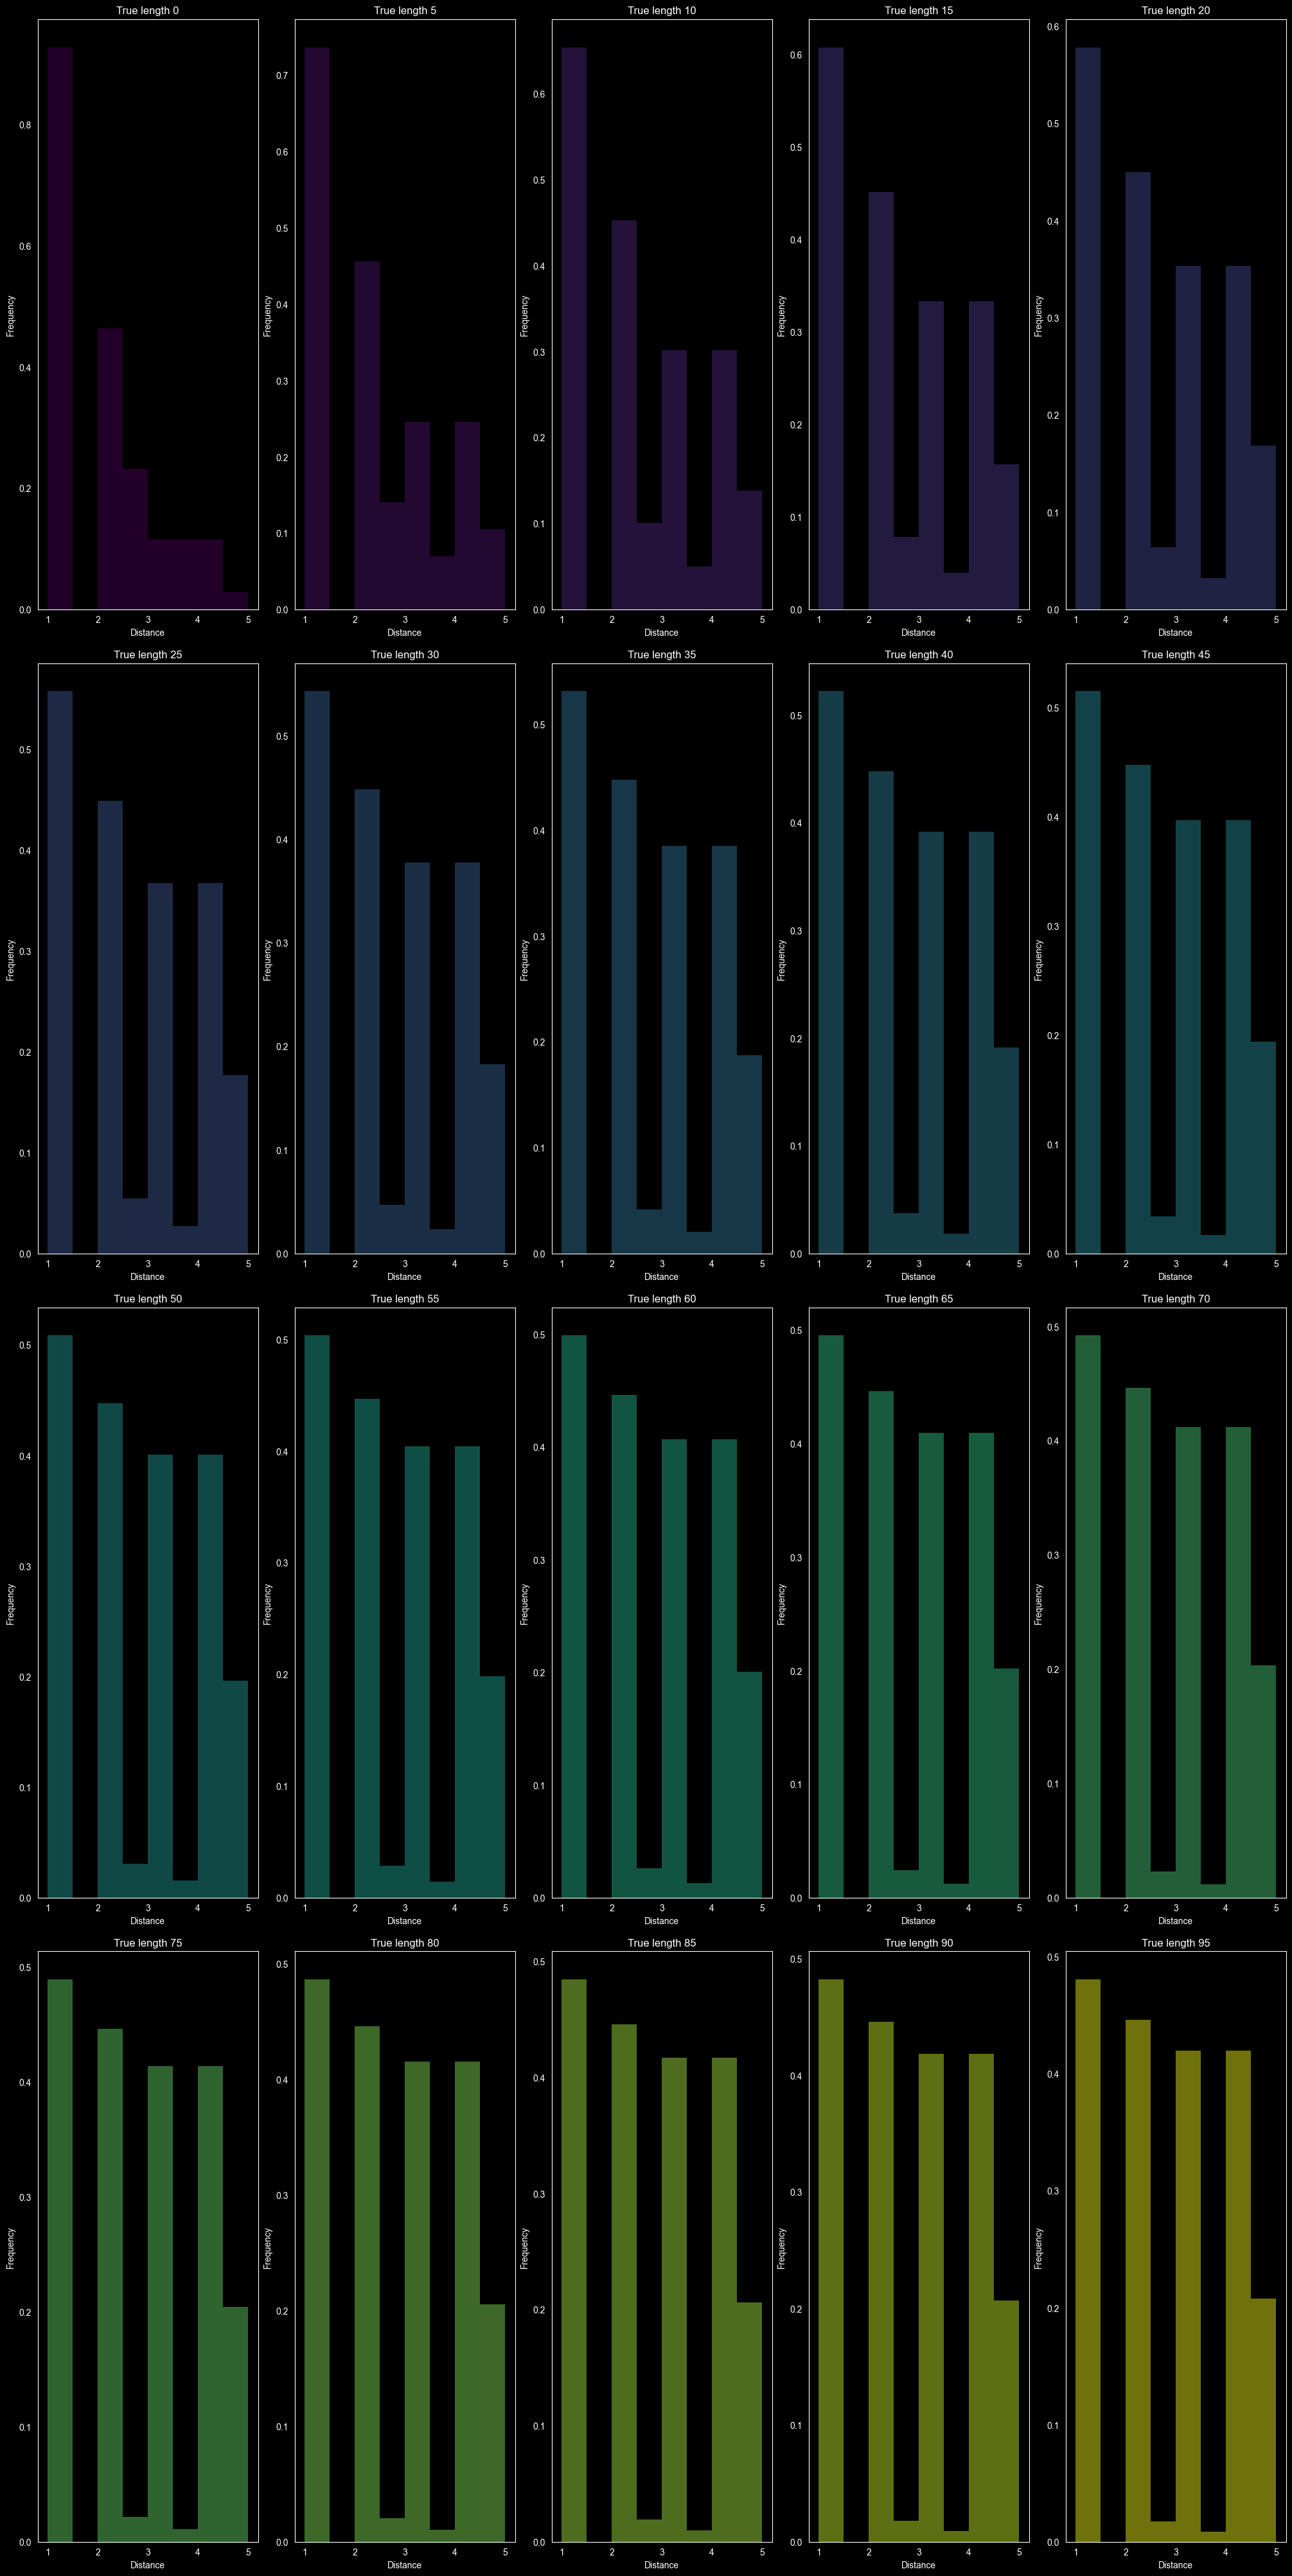

In [ ]:
import matplotlib.pyplot as plt

# Define properties for the histogram plot
n_bins = 2*r
alpha = 0.5  # Transparency level

# Number of rows and columns for the grid
N = len(lengths)
n_cols = 5
n_rows = N//n_cols

# Create a colormap
cmap = mpl.colormaps['viridis']
colors = cmap(np.linspace(0, 1, len(dists)))

# Plot histograms in a grid
fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, 40), constrained_layout=True, dpi=100)
sel = np.arange(0,N,N/(n_rows*n_cols)).astype(int)
dsel = [dists[i] for i in sel]
csel = [colors[i] for i in sel]
lsel = [lengths[i] for i in sel]

for ax, d, l, c in zip(axes.flatten(), dsel, lsel, csel):
    ax.hist(d[d > 0], bins=n_bins, alpha=alpha, edgecolor='none', color=c, density=1)
    ax.set_xlabel('Distance')
    ax.set_ylabel('Frequency')
    ax.grid(False)
    ax.set_title(f'True length {l}')
    

# Display the plot
plt.show()

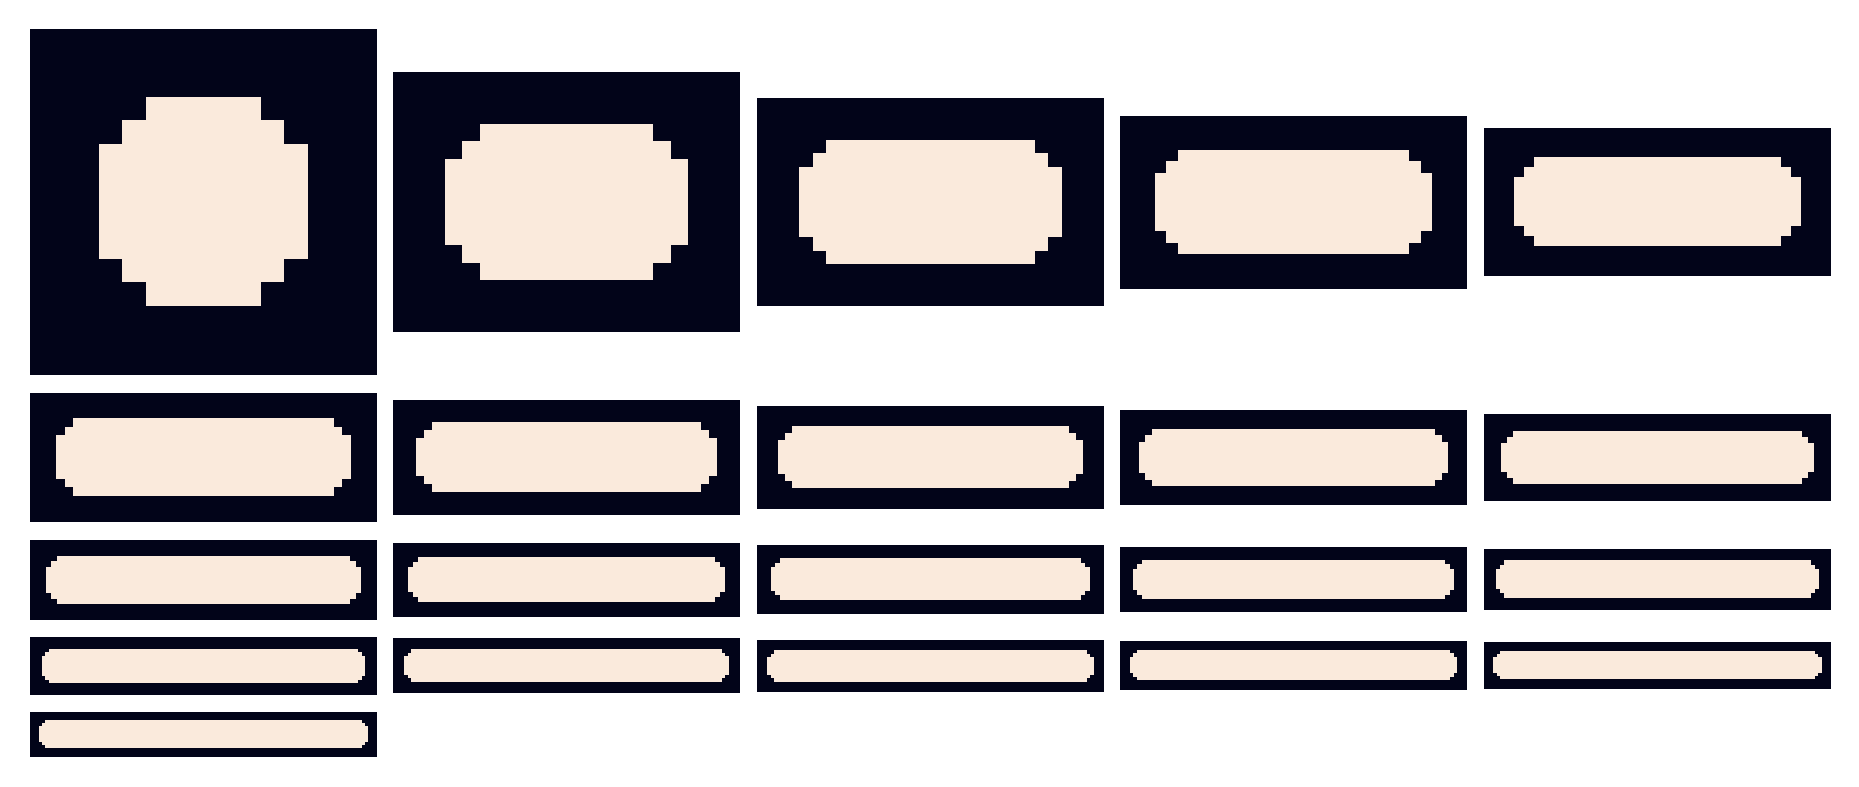

In [ ]:
from omnirefactor.plot import image_grid, split_list
f = image_grid(split_list(pills,5))

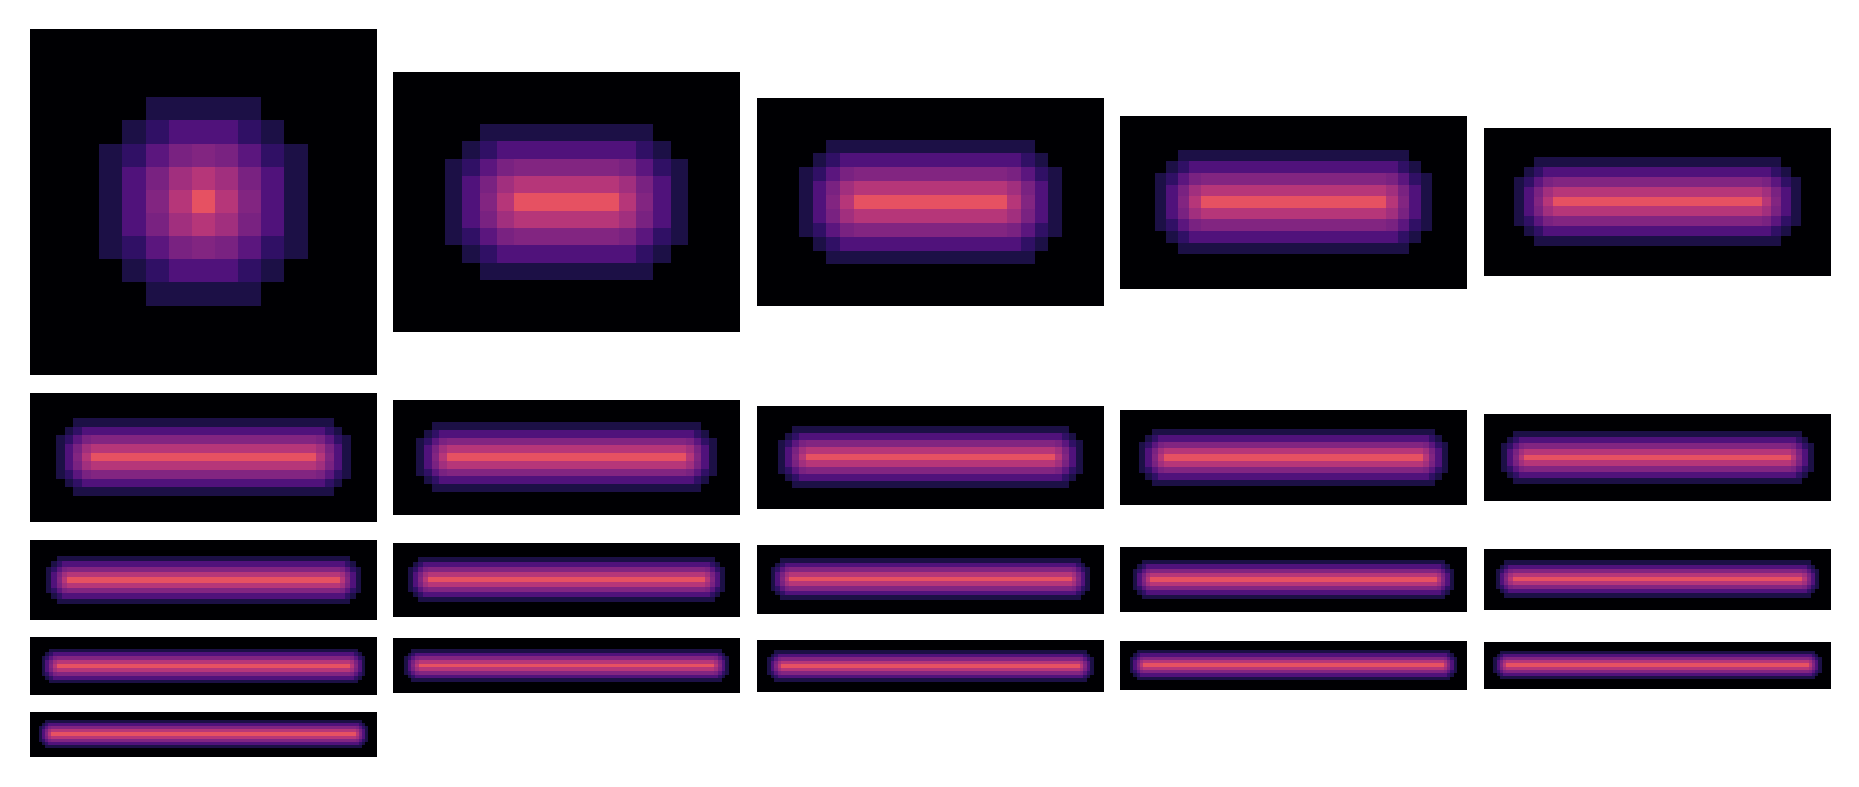

In [ ]:
from omnirefactor.plot import image_grid, split_list
cmap = mpl.colormaps['magma']
f = image_grid(split_list([cmap(d/(2*r)) for d in dists],5))

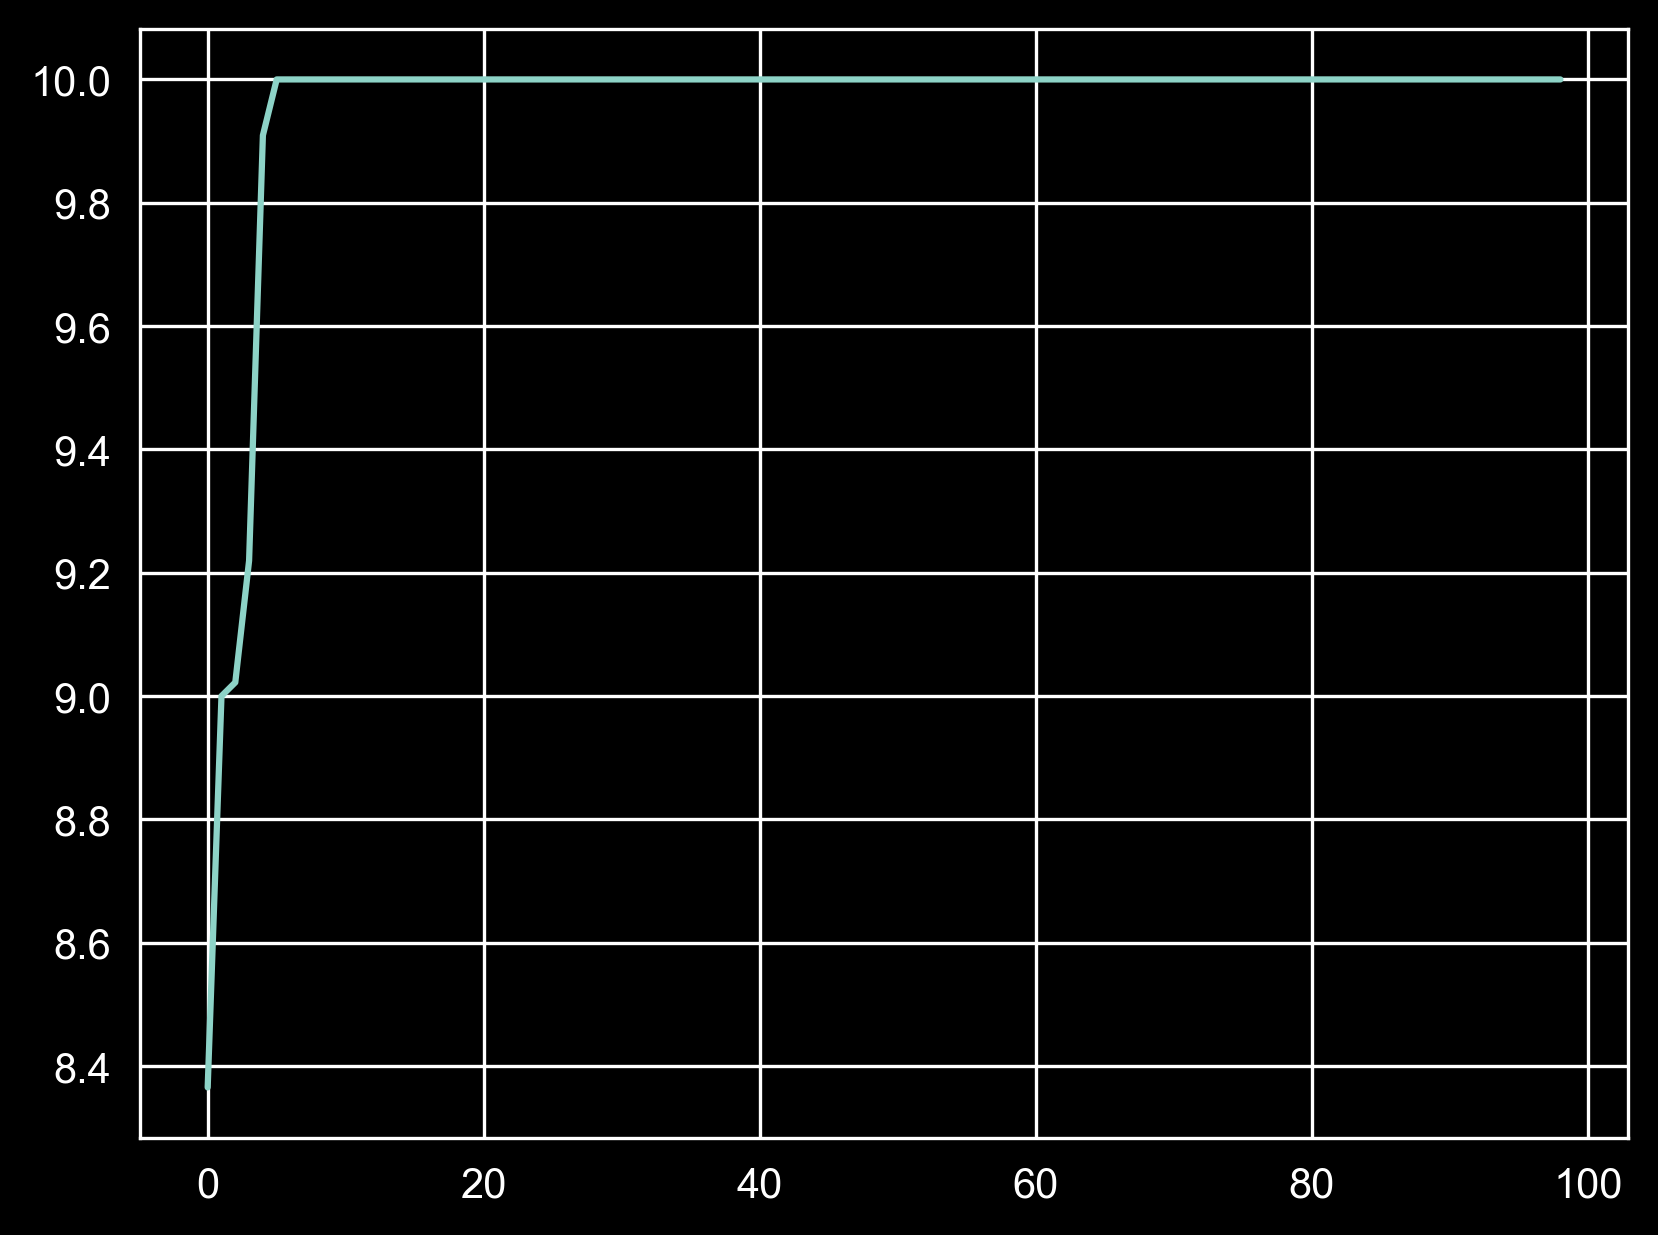

In [ ]:
readout = np.zeros(N)
DA = np.zeros(N)
for k,d in enumerate(dists):
    dt_pos = d[d>0]
    unq,cts = np.unique(dt_pos,return_counts=True)
    unq,cts
    sort = np.argsort(cts)
    unq[sort],cts[sort]
    max_idx = np.argmax(unq)
    min_idx = np.argmin(unq)
    # ratio[k] = cts[min_idx]/cts[max_idx]
    # readout[k] = unq[max_idx]
    
    # readout[k] = cts[max_idx]
    readout[k] = np.quantile(dt_pos,.9)
    
    
    DA[k] = np.sum(dt_pos)
p = plt.plot(readout)

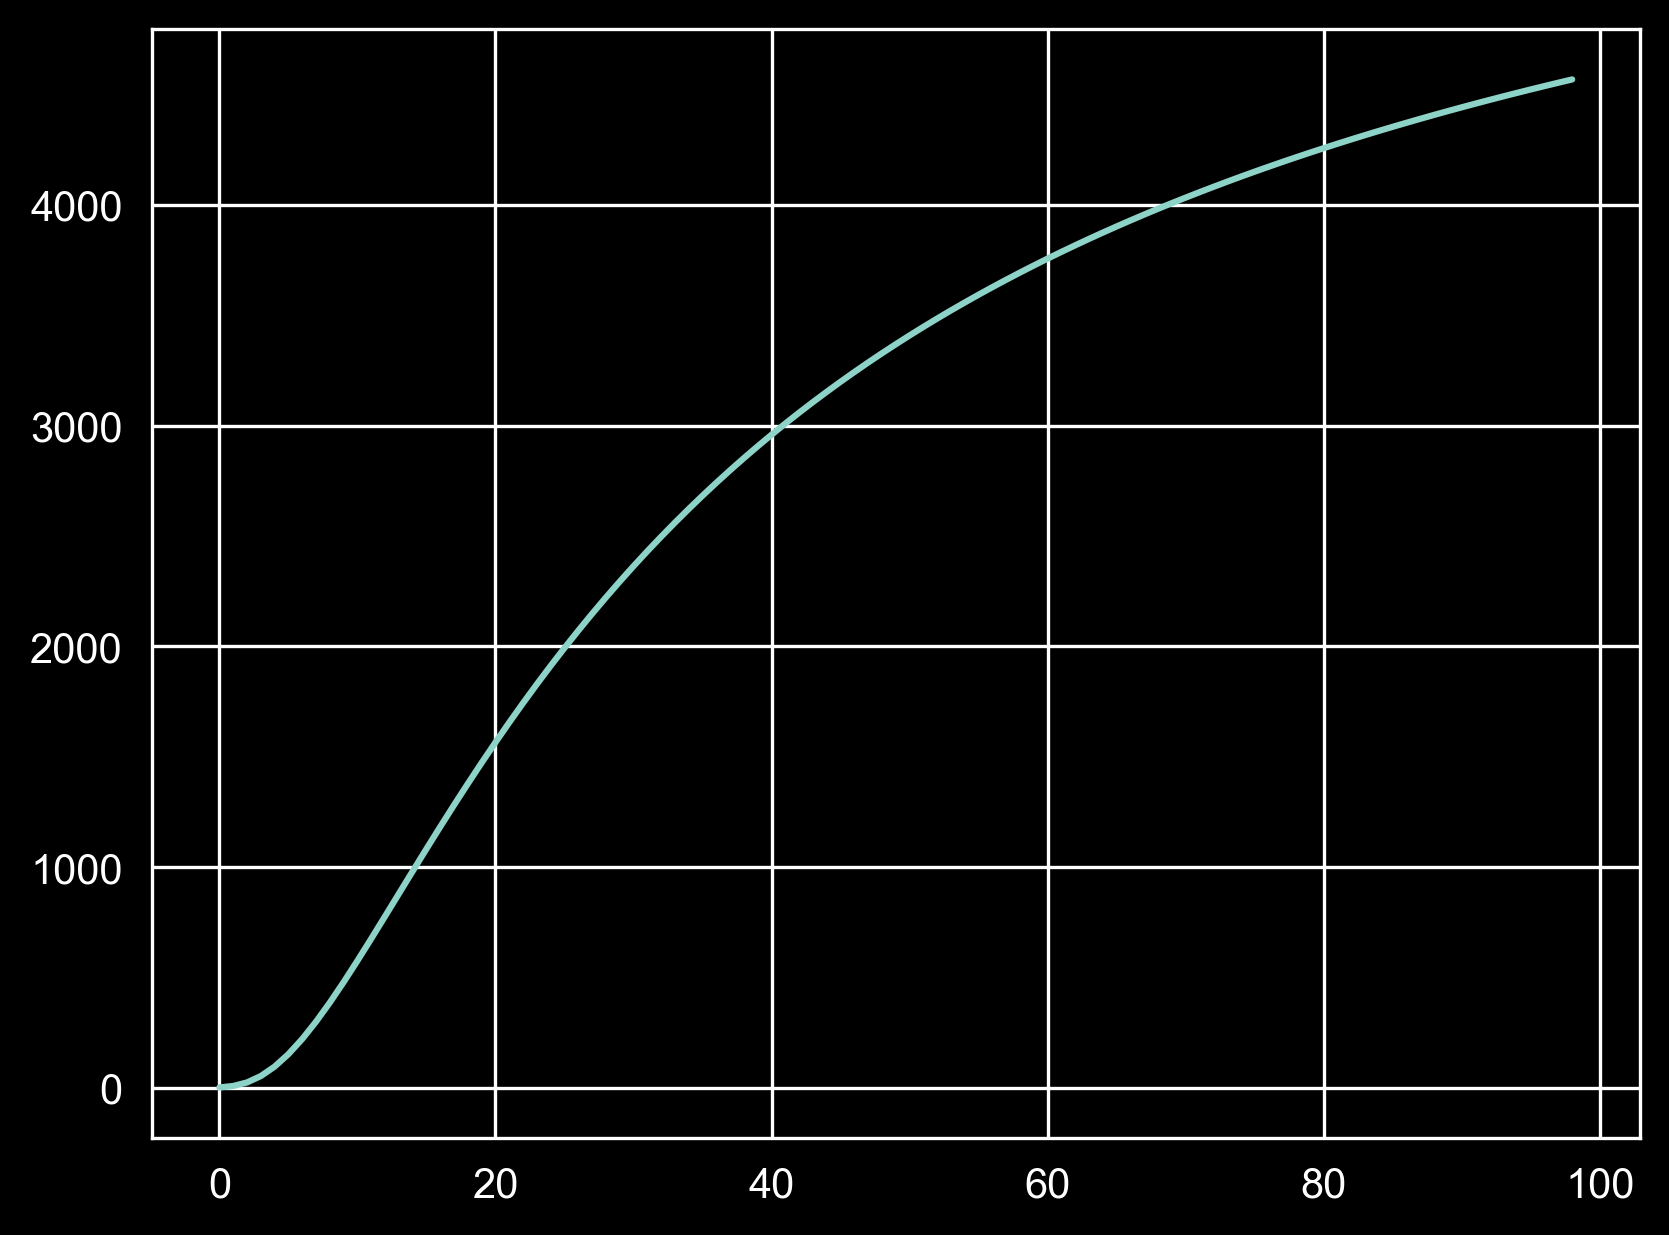

In [ ]:
p = plt.plot((DA/A)**(10/ratio))

In [ ]:
import edt
def get_skels(masks):
    skels = [[]]*len(masks)
    for k,m in enumerate(masks):
        dt = edt.edt(m)
        inner = dt>2
        skels[k] = skeletonize(inner, method='lee')
        
    return skels
skels = get_skels(pills)
sl = np.array([s.sum() for s in skels])
dm = np.array([d[s!=0].mean() for d,s in zip(dists,skels)])

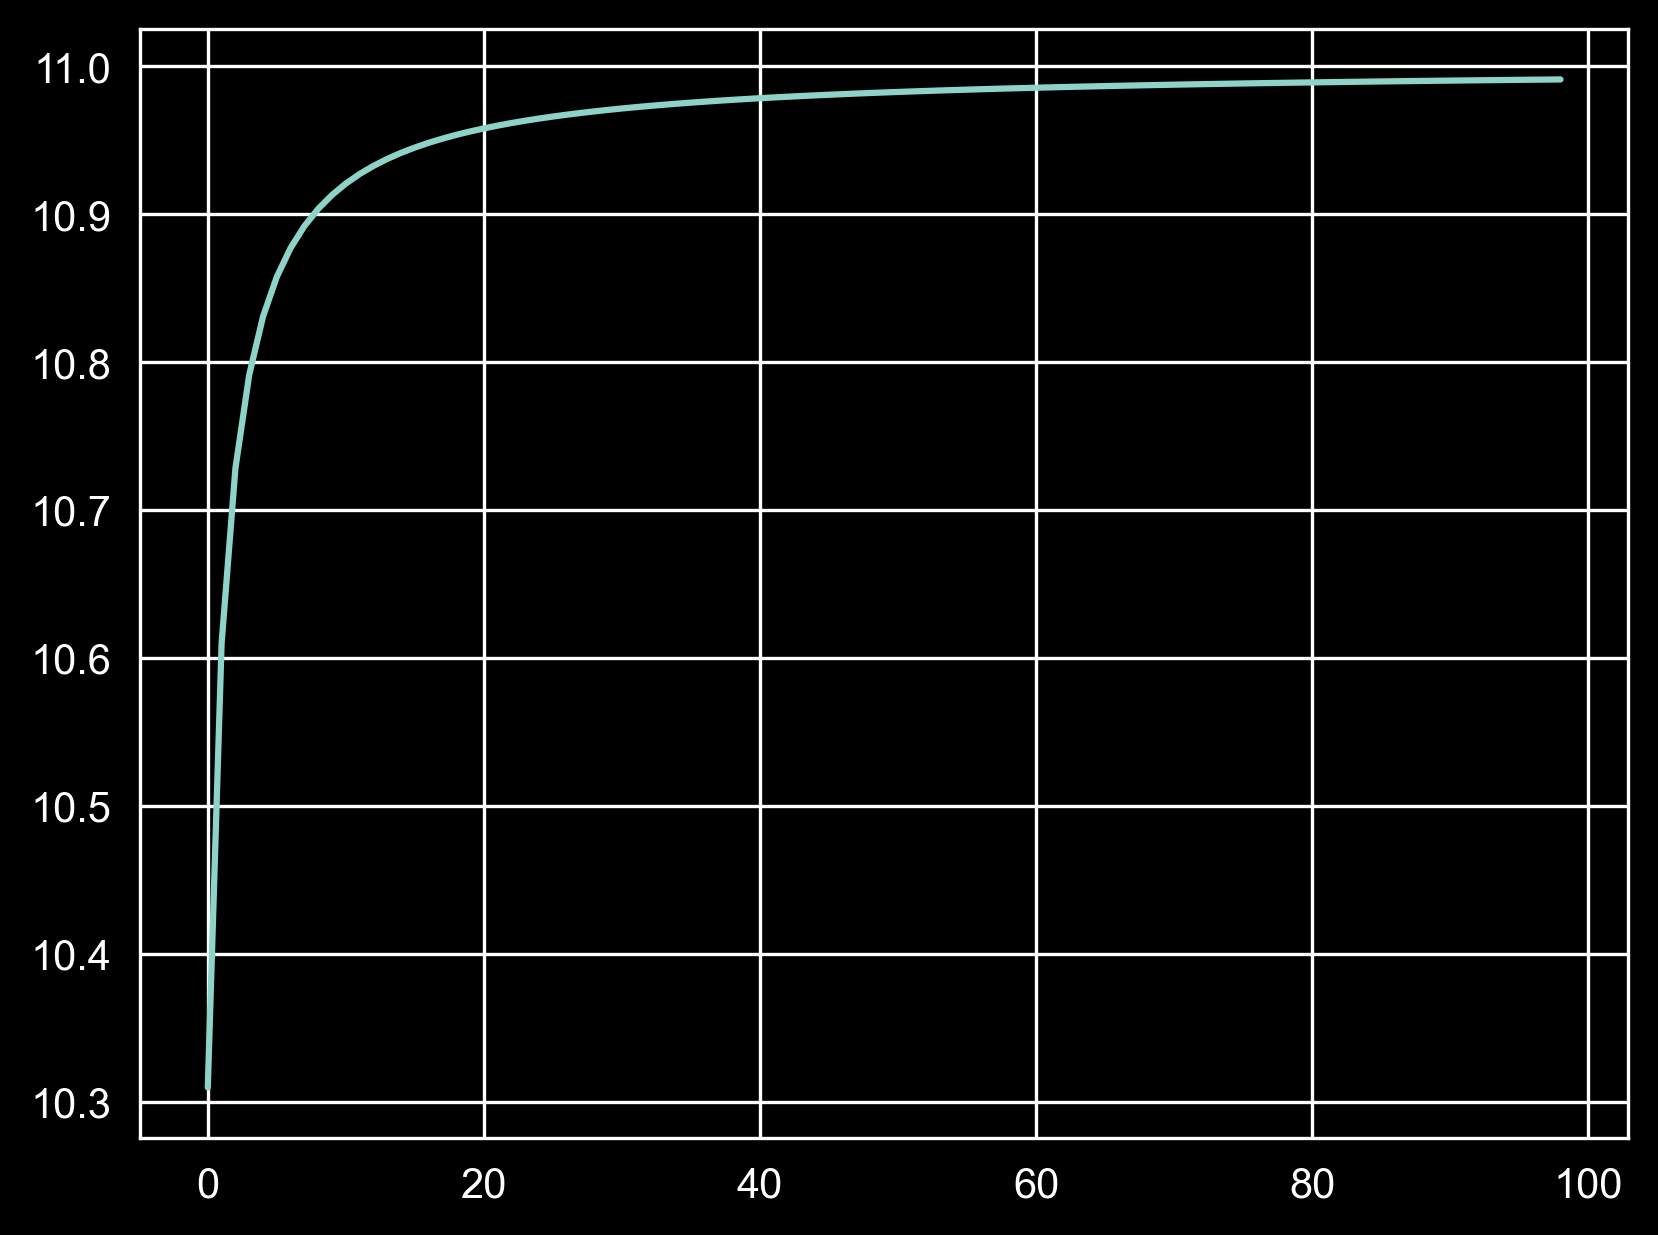

In [ ]:
plt.plot(dm)

5.745589


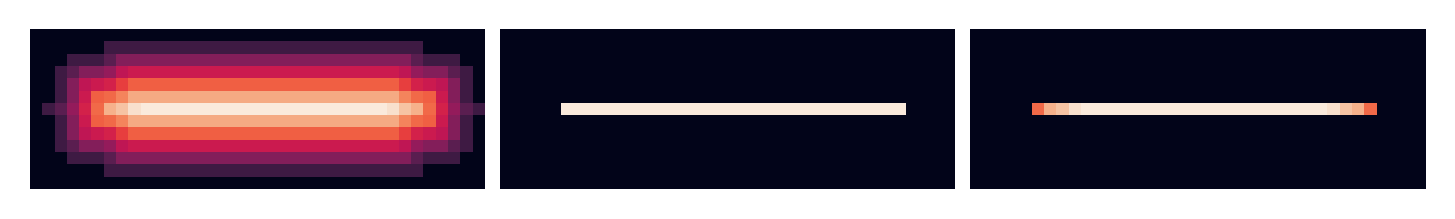

In [ ]:
k = 5
s,d= skels[k],dists[k]
print(d[s!=0].mean())
imshow([d,s,d*s])

In [ ]:
flows = omnirefactor.core.labels_to_flows(pills)
smooth_dists = [f[-1] for f in flows]
gradients = [f[-3:-1] for f in flows]
mag = [np.sqrt(np.sum(dP**2,axis=0)) for dP in gradients]


2024-06-27 23:23:53,965	[INFO]	                    	 line 276	NOTE: computing flows for labels (could be done before to save time)


100%|██████████████████████████████████████████| 21/21 [00:00<00:00, 382.96it/s]


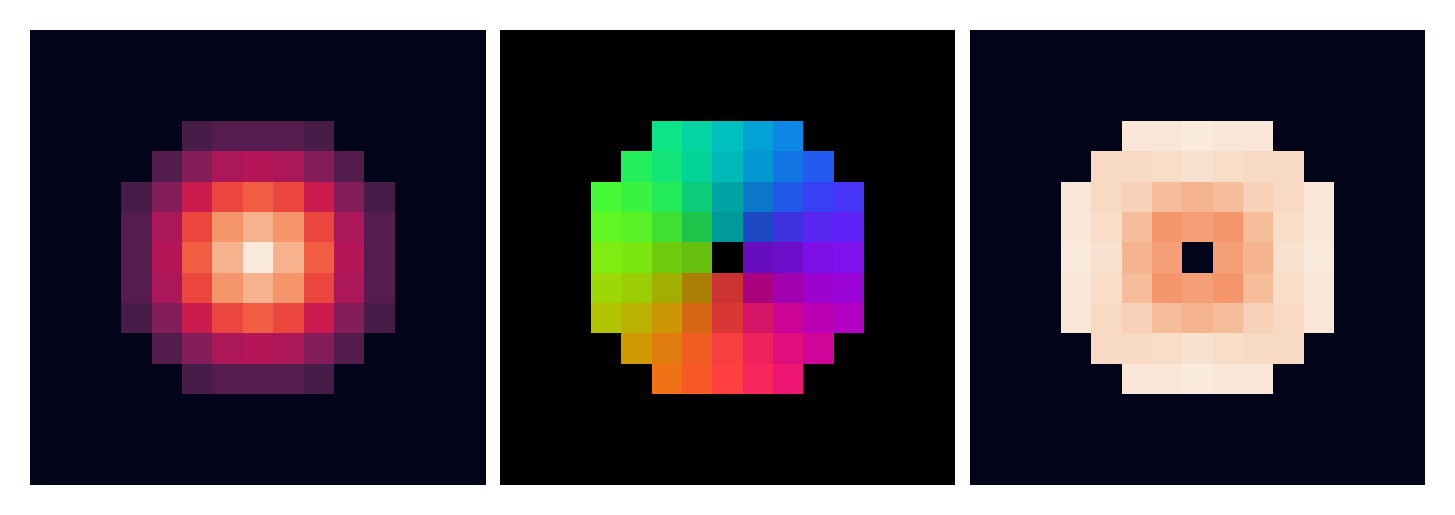

In [ ]:
import omnirefactor
imshow([smooth_dists[0],omnirefactor.plot.dx_to_circ(gradients[0]),mag[0]])

In [ ]:
res = np.zeros(N)
for k in range(N):
    mask = pills[k]>0
    # d = smooth_dists[k]
    d = dists[k]
    # m = mag[k]
    # w = m<0.5
    # div = omnirefactor.core.divergence(gradients[k])
    # dv = np.sum(div[mask])/np.sum(mask)

    dP = np.stack(np.gradient(d))
    m = np.sqrt(np.sum(dP**2,axis=0))
    w = m<0.5

    res[k] = np.sum(w[mask]*d[mask])/np.sum(w[mask])

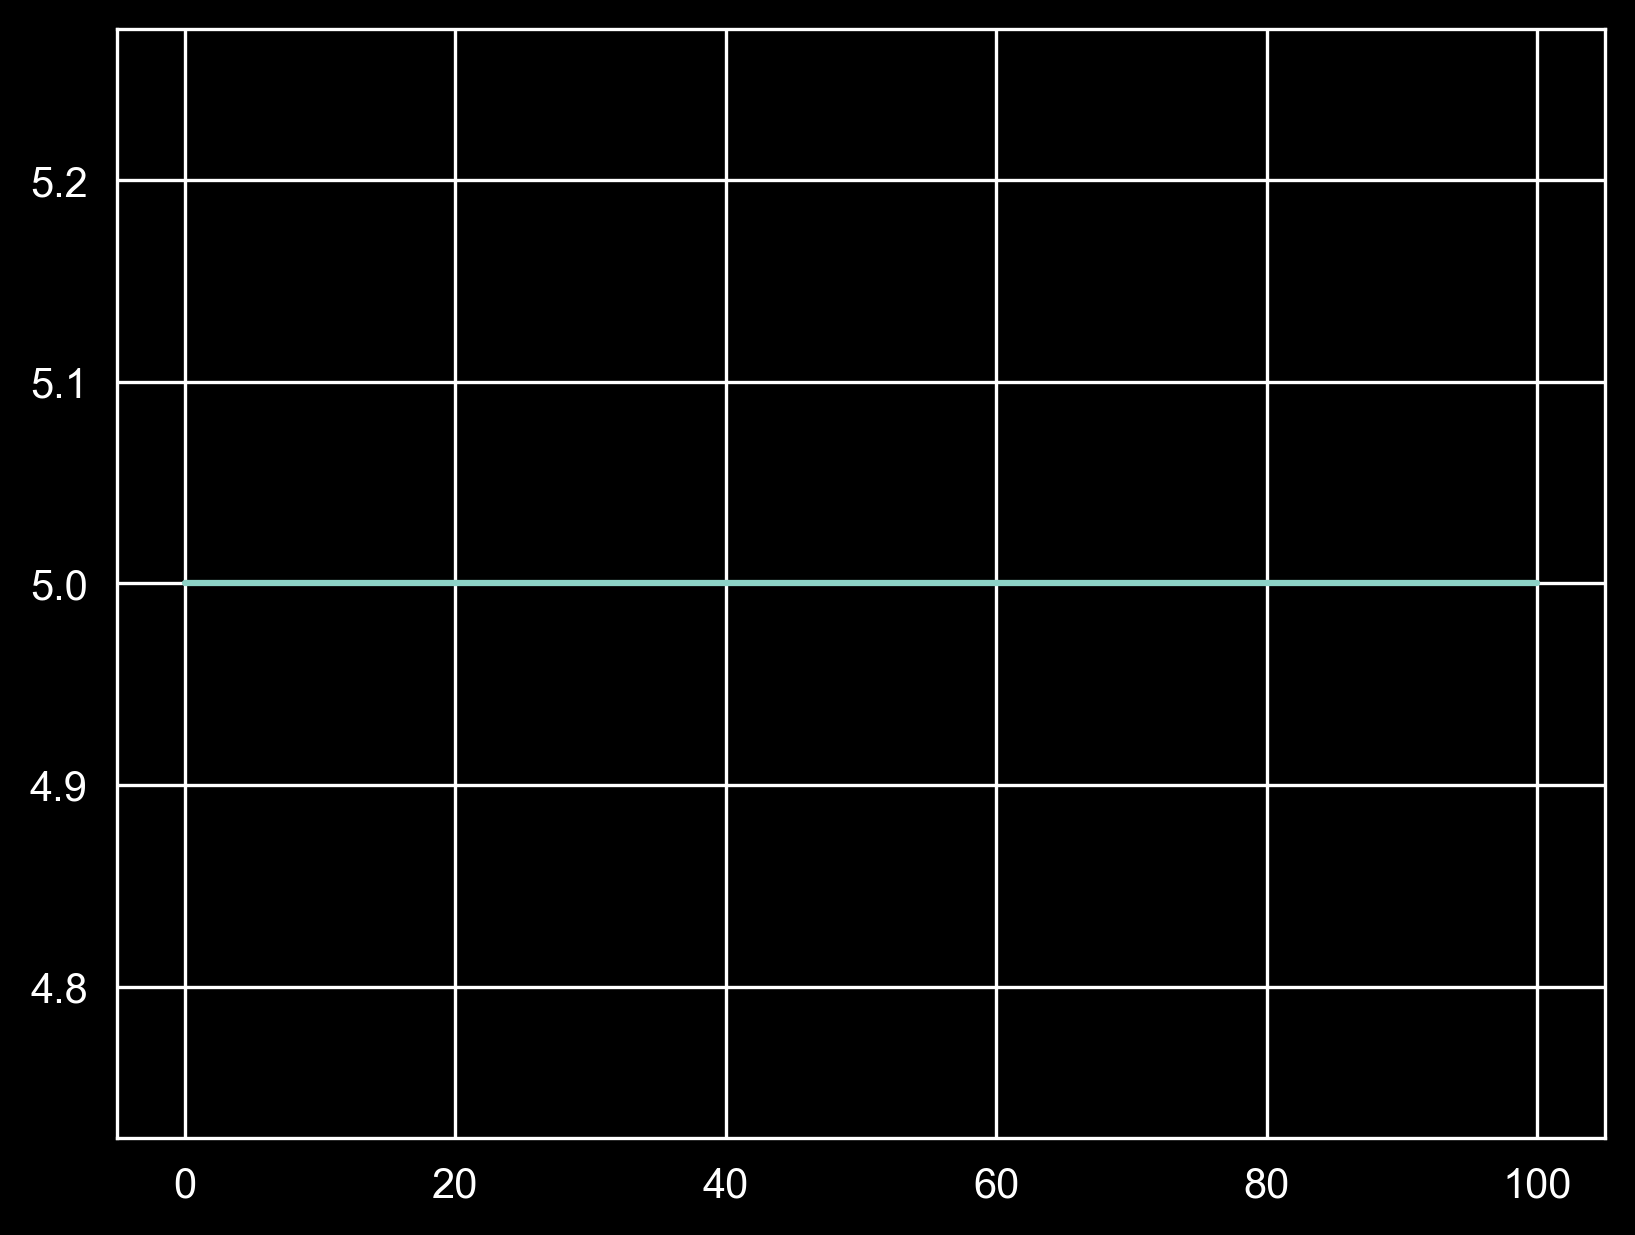

In [ ]:
p = plt.plot(lengths,res)


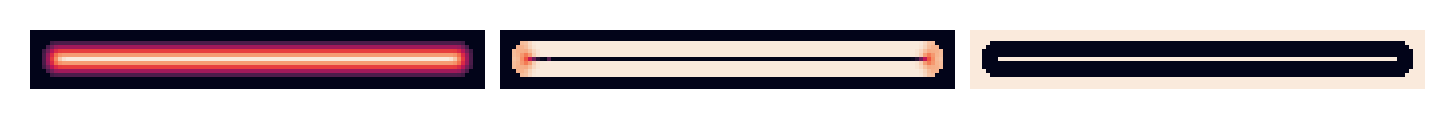

(-0.012564413009151336, 4.985883958268873, 5.0)

In [ ]:
k = -1
# k= 0
mask = pills[k]>0
# d = smooth_dists[k]
d = smooth_dists[k]

m = mag[k]
# w = (1-omnirefactor.utils.rescale(m))*mask
# w = (1-m)*mask
w = m<0.5
# w **= 3

imshow([d,m,w])
div = omnirefactor.core.divergence(gradients[k])
mask2 = mask*(m>0.5)
dv = np.sum(div[mask2])/np.sum(mask2)
# dv = np.sum(div[mask])/np.sum(mask)

dv, np.sum(w[mask]*d[mask])/np.sum(w[mask]), dists[k].max()

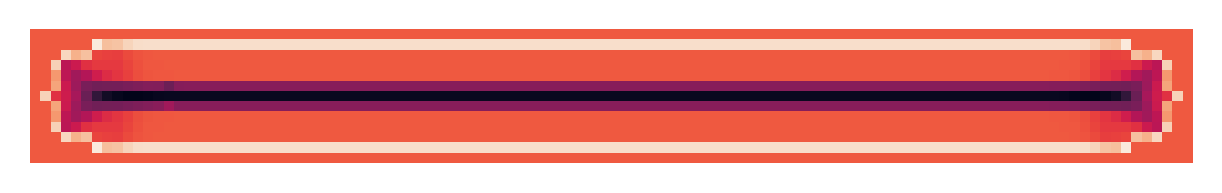

In [ ]:
imshow(omnirefactor.core.divergence(gradients[k])*mask,5)

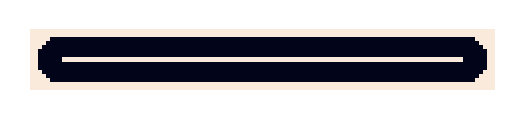

In [ ]:
dP = np.stack(np.gradient(d))
mag = np.sqrt(np.sum(dP**2,axis=0))
imshow(mag<0.5)

In [ ]:
m.max()

0.9257901